#Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error

# Set style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

#Pearson and Spearman Correlation

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

# Load data
try:
    df = pd.read_csv('Data_for_Model_v3.csv')
    npl_df = pd.read_csv('Data-NPL_baru.csv')
except FileNotFoundError as e:
    print(f"Error loading data file: {e}. Pastikan file ada di direktori yang benar.")
    exit()

In [3]:
# List of columns to interpolate
cols_to_interpolate = [
    'Garis_Kemiskinan',
    'Indeks_Pembangunan_Manusia',
    'Persen_Penduduk_Miskin',
    'Tingkat Pengangguran Terbuka',
    'Jumlah Penduduk (Ribu)',
    'Gini_Ratio'
]

# Sort the dataframe by kabupaten_kota, tahun, and kuartal to ensure correct interpolation
df = df.sort_values(by=['kabupaten_kota', 'tahun', 'kuartal']).reset_index(drop=True)

# Identify and set constant values in Q2-Q4 to NaN within each kabupaten_kota and tahun group
for col in cols_to_interpolate:
    df[col] = df.groupby(['kabupaten_kota', 'tahun'])[col].transform(lambda x: x if x.nunique() > 1 else x.where(x.index % 4 == 0))

# Apply linear interpolation within each kabupaten_kota group
for col in cols_to_interpolate:
    df[col] = df.groupby('kabupaten_kota')[col].transform(lambda x: x.interpolate(method='linear'))

print("Interpolation applied to specified columns for Q2-Q4 constant values.")

# Display the head of the modified dataframe to show the changes
display(df.head())

Interpolation applied to specified columns for Q2-Q4 constant values.


,kabupaten_kota,Garis_Kemiskinan,Indeks_Pembangunan_Manusia,Persen_Penduduk_Miskin,Tingkat Pengangguran Terbuka,Upah Minimum,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk,tahun,kuartal,PDRB,Proksi Inflasi,Laju_Inflasi,Gini_Ratio,investasi_per_kapita,Jumlah Perusahaan Kecil
0,BANGKALAN,458754.00,66.1100,19.4400,8.0500,1956773.48,1081.7500,1.25,2.62,954.5,97.4,2022,1.0,4144.62,Kota Surabaya,3.16,0.30600,331.467391,38
1,BANGKALAN,469867.25,66.2875,19.4175,7.5825,1956773.48,1084.2625,1.25,2.62,954.5,97.4,2022,2.0,4184.80,Kota Surabaya,4.89,0.30425,986.404348,37
2,BANGKALAN,480980.50,66.4650,19.3950,7.1150,1956773.48,1086.7750,1.25,2.62,954.5,97.4,2022,3.0,4481.15,Kota Surabaya,6.91,0.30250,1527.247619,39
3,BANGKALAN,492093.75,66.6425,19.3725,6.6475,1956773.48,1089.2875,1.25,2.62,954.5,97.4,2022,4.0,4149.34,Kota Surabaya,6.59,0.30075,1103.961538,44
4,BANGKALAN,503207.00,66.8200,19.3500,6.1800,2240701.00,1091.8000,1.07,2.63,839.0,97.6,2023,1.0,4304.99,Kota Surabaya,6.3,0.29900,2403.400000,46


In [4]:
# Preprocessing data NPL: Ubah format Kuartal menjadi numerik
npl_df['Kuartal'] = npl_df['Kuartal'].str.replace('Q', '').astype(float)
npl_df['Tahun'] = npl_df['Tahun'].astype(int)

# Pastikan data df sudah sorted by tahun dan kuartal
df = df.sort_values(by=['tahun', 'kuartal']).reset_index(drop=True)

# --- LAKUKAN PEMISAHAN DATA BERDASARKAN WAKTU (TRAIN-TEST SPLIT) ---
# Tentukan titik pisah (misal: data sebelum 2024 Q1 untuk training, sisanya untuk testing)
split_year = 2024
split_quarter = 1

train_mask = (df['tahun'] < split_year) | ((df['tahun'] == split_year) & (df['kuartal'] < split_quarter))
test_mask = ~train_mask

df_train = df[train_mask].reset_index(drop=True)
df_test = df[test_mask].reset_index(drop=True)

print(f"Shape of df_train: {df_train.shape}")
print(f"Shape of df_test: {df_test.shape}\n")


# Pilih kolom numerik untuk PCA (exclude kolom identifier dan target sementara)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
exclude_cols = ['tahun', 'kuartal','Jumlah Perusahaan Kecil'] # Exclude identifiers for PCA features
pca_cols = [col for col in numeric_cols if col not in exclude_cols]


# --- LAKUKAN STANDARDISASI DAN PCA HANYA PADA DATA TRAINING ---
scaler = StandardScaler()
df_train_scaled = scaler.fit_transform(df_train[pca_cols])

# Fit PCA pada data training yang sudah distandardisasi
pca = PCA()
pca.fit(df_train_scaled)

# Tentukan jumlah komponen untuk menjelaskan >90% varians (berdasarkan data training)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of PCA components explaining >90% variance (from training data): {n_components}\n")


# Ulangi PCA dengan n_components yang optimal, fit pada training, transform pada train & test
pca = PCA(n_components=n_components)
pca_scores_train = pca.fit_transform(df_train_scaled) # Fit and transform on training
df_test_scaled = scaler.transform(df_test[pca_cols]) # Transform test data using scaler fitted on training
pca_scores_test = pca.transform(df_test_scaled) # Transform test data using PCA fitted on training


# Buat DataFrame hasil PCA untuk training dan testing
pca_columns = [f'PC{i+1}' for i in range(n_components)]

pca_df_train = pd.DataFrame(pca_scores_train, columns=pca_columns)
pca_df_train = pd.concat([df_train[['kabupaten_kota', 'tahun', 'kuartal']].reset_index(drop=True), pca_df_train], axis=1)

pca_df_test = pd.DataFrame(pca_scores_test, columns=pca_columns)
pca_df_test = pd.concat([df_test[['kabupaten_kota', 'tahun', 'kuartal']].reset_index(drop=True), pca_df_test], axis=1)

# Gabungkan kembali training dan testing pca_df untuk langkah selanjutnya (perhitungan skor, dll)
# pca_df = pd.concat([pca_df_train, pca_df_test]).reset_index(drop=True) # Menghapus baris ini
# df = pd.concat([df_train, df_test]).reset_index(drop=True) # Menghapus baris ini

Shape of df_train: (304, 19)
Shape of df_test: (152, 19)

Number of PCA components explaining >90% variance (from training data): 6



##Identifikasi PC Loading

In [5]:
import pandas as pd

# Buat DataFrame untuk melihat loadings
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=pca_cols
)

# Tampilkan loadings untuk semua PC
print("PCA Loadings (All Components):")
display(loadings_df)

# Analisis:
# - Variabel dengan nilai absolut tinggi adalah kontributor utama PC tersebut.
# - Beri nama setiap PC berdasarkan tema variabelnya (mis. "PC1: Faktor Kesejahteraan", "PC2: Faktor Pertumbuhan").

PCA Loadings (All Components):


,PC1,PC2,PC3,PC4,PC5,PC6
Garis_Kemiskinan,0.361256,-0.104907,-0.251388,0.056462,-0.428767,0.089626
Indeks_Pembangunan_Manusia,0.414969,-0.091095,0.063922,-0.069408,0.027454,-0.104631
Persen_Penduduk_Miskin,-0.364556,0.037872,-0.276395,0.113199,-0.329966,0.248116
Tingkat Pengangguran Terbuka,0.294000,0.166986,0.333582,0.000689,0.022728,0.829347
Upah Minimum,0.272689,0.292367,-0.009752,0.160034,-0.319477,-0.336555
Jumlah Penduduk (Ribu),0.019790,0.528640,-0.121906,0.034105,0.086164,0.060891
Laju Pertumbuhan Penduduk per Tahun,0.275225,-0.322620,0.057008,0.202492,-0.282689,0.018743
Persentase Penduduk,0.019367,0.528695,-0.121469,0.033278,0.088148,0.064340
Kepadatan Penduduk per km persegi (Km2),0.384070,-0.142098,-0.251809,-0.029881,0.004512,0.090006
Rasio Jenis Kelamin Penduduk,0.089407,0.213508,0.725272,0.131573,-0.161595,-0.269338


In [6]:
# --- Langkah 1.4: Menyesuaikan Arah Risiko Berdasarkan Interpretasi Loadings ---

print("Arah PC sebelum disesuaikan (contoh dari train set):")
display(pca_df_train.head()) # Use pca_df_train

# Daftar PC yang akan dibalik tandanya berdasarkan analisis interpretasi
# PC yang bernilai tinggi menandakan RISIKO RENDAH, sehingga perlu diinversi.
pcs_to_invert = ['PC1', 'PC2', 'PC4'] # Example based on previous interpretation

# Lakukan inversi tanda pada DataFrame train dan test
for pc in pcs_to_invert:
    if pc in pca_df_train.columns: # Use pca_df_train
        pca_df_train[pc] = pca_df_train[pc] * -1 # Use pca_df_train
        pca_df_test[pc] = pca_df_test[pc] * -1 # Use pca_df_test
        print(f"Arah untuk {pc} telah dibalik.")

print("\nArah PC setelah disesuaikan (contoh dari train set):")
display(pca_df_train.head()) # Use pca_df_train

Arah PC sebelum disesuaikan (contoh dari train set):


,kabupaten_kota,tahun,kuartal,PC1,PC2,PC3,PC4,PC5,PC6
0,BANGKALAN,2022,1.0,-1.842970,0.102720,-0.293791,0.280448,-0.802918,3.202456
1,BANYUWANGI,2022,1.0,-0.541034,1.430486,0.734724,-0.092896,0.645599,0.164598
2,BATU,2022,1.0,1.912281,-1.385212,2.553576,0.340736,-1.230947,1.277930
3,BLITAR,2022,1.0,-0.959681,0.613675,1.568813,-0.140965,0.836995,0.213842
4,BOJONEGORO,2022,1.0,-1.823379,1.013488,0.716371,0.238196,-0.485284,0.235090


Arah untuk PC1 telah dibalik.
Arah untuk PC2 telah dibalik.
Arah untuk PC4 telah dibalik.

Arah PC setelah disesuaikan (contoh dari train set):


,kabupaten_kota,tahun,kuartal,PC1,PC2,PC3,PC4,PC5,PC6
0,BANGKALAN,2022,1.0,1.842970,-0.102720,-0.293791,-0.280448,-0.802918,3.202456
1,BANYUWANGI,2022,1.0,0.541034,-1.430486,0.734724,0.092896,0.645599,0.164598
2,BATU,2022,1.0,-1.912281,1.385212,2.553576,-0.340736,-1.230947,1.277930
3,BLITAR,2022,1.0,0.959681,-0.613675,1.568813,0.140965,0.836995,0.213842
4,BOJONEGORO,2022,1.0,1.823379,-1.013488,0.716371,-0.238196,-0.485284,0.235090


##Calculating Composite_Risk_Score_Normalized

In [7]:
# Dapatkan bobot varians dari PCA yang sudah di-fit pada data latih
# Gunakan objek 'pca' yang sudah di-fit pada data training di sel sebelumnya
variance_ratios = pca.explained_variance_ratio_

# Hitung skor komposit terbobot untuk train dan test set
# Gunakan DataFrame PCA yang arahnya sudah disesuaikan dari langkah 1.4 (pca_df_train dan pca_df_test)
# Pastikan kolom PC di pca_df_train dan pca_df_test sudah disesuaikan arahnya jika diperlukan
pca_df_train['Composite_Risk_Score'] = pca_df_train[pca_columns].dot(variance_ratios)
pca_df_test['Composite_Risk_Score'] = pca_df_test[pca_columns].dot(variance_ratios)


# Normalisasi skor akhir ini secara terpisah untuk train dan test set
# Inisialisasi scaler
scaler_risk = StandardScaler()

# Fit HANYA pada data training dan transform
pca_df_train['Composite_Risk_Score_Normalized'] = scaler_risk.fit_transform(pca_df_train[['Composite_Risk_Score']])

# Transform data testing menggunakan scaler yang sama
pca_df_test['Composite_Risk_Score_Normalized'] = scaler_risk.transform(pca_df_test[['Composite_Risk_Score']])

print("Skor risiko komposit terbobot berhasil dihitung dan dinormalisasi tanpa data leakage.")
display(pca_df_train.head())
display(pca_df_test.head())

Skor risiko komposit terbobot berhasil dihitung dan dinormalisasi tanpa data leakage.


,kabupaten_kota,tahun,kuartal,PC1,PC2,PC3,PC4,PC5,PC6,Composite_Risk_Score,Composite_Risk_Score_Normalized
0,BANGKALAN,2022,1.0,1.842970,-0.102720,-0.293791,-0.280448,-0.802918,3.202456,0.687982,0.705858
1,BANYUWANGI,2022,1.0,0.541034,-1.430486,0.734724,0.092896,0.645599,0.164598,-0.028313,-0.029049
2,BATU,2022,1.0,-1.912281,1.385212,2.553576,-0.340736,-1.230947,1.277930,-0.190103,-0.195043
3,BLITAR,2022,1.0,0.959681,-0.613675,1.568813,0.140965,0.836995,0.213842,0.435644,0.446963
4,BOJONEGORO,2022,1.0,1.823379,-1.013488,0.716371,-0.238196,-0.485284,0.235090,0.469974,0.482185


,kabupaten_kota,tahun,kuartal,PC1,PC2,PC3,PC4,PC5,PC6,Composite_Risk_Score,Composite_Risk_Score_Normalized
0,BANGKALAN,2024,1.0,1.802362,0.009876,-0.965653,-0.384913,-1.411601,1.513912,0.530272,0.544049
1,BANYUWANGI,2024,1.0,0.350715,-1.458134,0.305576,-0.068356,0.000571,-0.670902,-0.231665,-0.237684
2,BATU,2024,1.0,-1.467019,1.469421,1.215101,-0.078306,-1.150458,-1.666488,-0.206853,-0.212227
3,BLITAR,2024,1.0,0.436164,-0.547920,1.180401,0.177484,0.774532,-0.354451,0.193739,0.198773
4,BOJONEGORO,2024,1.0,1.023916,-0.975813,0.391163,-0.122429,-0.407645,-0.166413,0.142711,0.146419


In [8]:
# 2. Lakukan agregasi pada masing-masing set data secara terpisah.
agg_risk_train = pca_df_train.groupby(['tahun', 'kuartal'])['Composite_Risk_Score_Normalized'].sum().reset_index()
agg_risk_test = pca_df_test.groupby(['tahun', 'kuartal'])['Composite_Risk_Score_Normalized'].sum().reset_index()

# 3. Jika Anda memerlukan satu tabel gabungan untuk analisis korelasi, gabungkan hasil agregasinya.
province_composite_risk_score = pd.concat([agg_risk_train, agg_risk_test]).reset_index(drop=True)

# 4. Ubah nama kolom.
province_composite_risk_score.rename(columns={'Composite_Risk_Score_Normalized': 'Aggregated_Composite_Risk_Score_Province'}, inplace=True)

# Menampilkan hasil yang secara fungsional sama, tetapi dengan proses yang lebih aman.
print("Aggregated Composite Risk Score (dengan metodologi yang lebih aman):")
display(province_composite_risk_score)

Aggregated Composite Risk Score (dengan metodologi yang lebih aman):


,tahun,kuartal,Aggregated_Composite_Risk_Score_Province
0,2022,1.0,4.541651
1,2022,2.0,3.633647
2,2022,3.0,2.722418
3,2022,4.0,1.978577
4,2023,1.0,-2.541658
5,2023,2.0,-3.672439
6,2023,3.0,-3.116069
7,2023,4.0,-3.546127
8,2024,1.0,-4.287122
9,2024,2.0,-4.745842


Pearson Korelasi antara Aggregated Composite Risk Score Provinsi dan NPL (lag 2 kuartal): 0.8533
Pearson P-value: 0.0008

Spearman Korelasi antara Aggregated Composite Risk Score Provinsi dan NPL (lag 2 kuartal): 0.9545
Spearman P-value: 0.000005



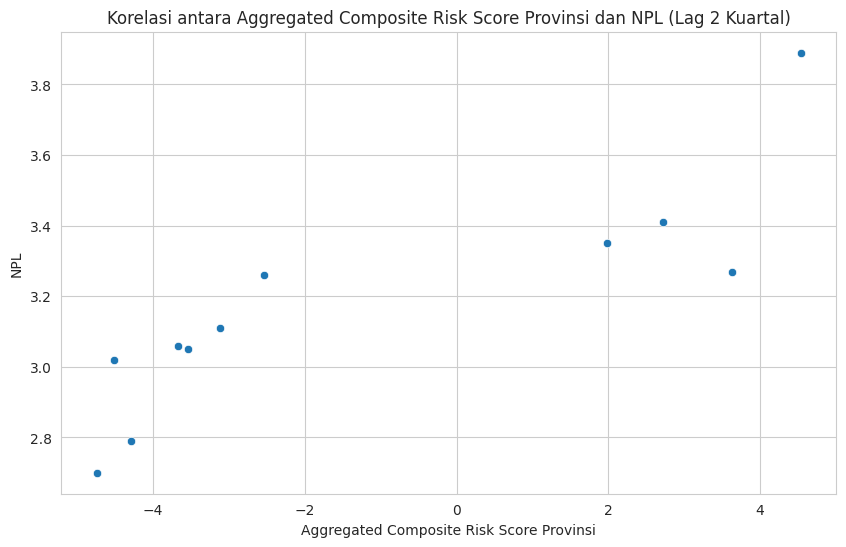

Data yang Digunakan untuk Korelasi:


,tahun,kuartal,Aggregated_Composite_Risk_Score_Province,NPL_Year,NPL_Quarter,NPL
0,2022,1.0,4.541651,2022,3.0,3.89
1,2022,2.0,3.633647,2022,4.0,3.27
2,2022,3.0,2.722418,2023,1.0,3.41
3,2022,4.0,1.978577,2023,2.0,3.35
4,2023,1.0,-2.541658,2023,3.0,3.26
5,2023,2.0,-3.672439,2023,4.0,3.06
6,2023,3.0,-3.116069,2024,1.0,3.11
7,2023,4.0,-3.546127,2024,2.0,3.05
8,2024,1.0,-4.287122,2024,3.0,2.79
9,2024,2.0,-4.745842,2024,4.0,2.70


In [9]:
# Persiapan untuk Korelasi dengan NPL (Lag 2 Kuartal)
province_composite_risk_score['NPL_Year'] = province_composite_risk_score['tahun']
province_composite_risk_score['NPL_Quarter'] = province_composite_risk_score['kuartal'] + 2

# Penyesuaian untuk kuartal > 4
province_composite_risk_score['NPL_Year'] = province_composite_risk_score['NPL_Year'] + (province_composite_risk_score['NPL_Quarter'] > 4).astype(int)
province_composite_risk_score['NPL_Quarter'] = province_composite_risk_score['NPL_Quarter'] % 4
province_composite_risk_score['NPL_Quarter'] = province_composite_risk_score['NPL_Quarter'].replace(0, 4)

# Gabungkan dengan data NPL
# Pastikan npl_df sudah dimuat dan diproses sebelumnya (ini sudah dilakukan di cell PV7JJbkjLaXO atau d2xTj0vYxqCU)
merged_correlation_df = province_composite_risk_score.merge(npl_df, left_on=['NPL_Year', 'NPL_Quarter'], right_on=['Tahun', 'Kuartal'], how='inner')

# --- Perhitungan dan Tampilan Hasil Korelasi ---
# Korelasi Pearson
pearson_corr, pearson_p_value = pearsonr(merged_correlation_df['Aggregated_Composite_Risk_Score_Province'], merged_correlation_df['NPL'])
print(f"Pearson Korelasi antara Aggregated Composite Risk Score Provinsi dan NPL (lag 2 kuartal): {pearson_corr:.4f}")
print(f"Pearson P-value: {pearson_p_value:.4f}\n")

# Korelasi Spearman
spearman_corr, spearman_p_value = spearmanr(merged_correlation_df['Aggregated_Composite_Risk_Score_Province'], merged_correlation_df['NPL'])
print(f"Spearman Korelasi antara Aggregated Composite Risk Score Provinsi dan NPL (lag 2 kuartal): {spearman_corr:.4f}")
print(f"Spearman P-value: {spearman_p_value:.6f}\n")

# --- Visualisasi ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_correlation_df, x='Aggregated_Composite_Risk_Score_Province', y='NPL')
plt.title('Korelasi antara Aggregated Composite Risk Score Provinsi dan NPL (Lag 2 Kuartal)')
plt.xlabel('Aggregated Composite Risk Score Provinsi')
plt.ylabel('NPL')
plt.show()

# Menampilkan data yang digunakan untuk korelasi
print("Data yang Digunakan untuk Korelasi:")
display(merged_correlation_df[['tahun', 'kuartal', 'Aggregated_Composite_Risk_Score_Province', 'NPL_Year', 'NPL_Quarter', 'NPL']])

#Model Training for Composite_Risk_Score_Normalized_t__

In [10]:
df

,kabupaten_kota,Garis_Kemiskinan,Indeks_Pembangunan_Manusia,Persen_Penduduk_Miskin,Tingkat Pengangguran Terbuka,Upah Minimum,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk,tahun,kuartal,PDRB,Proksi Inflasi,Laju_Inflasi,Gini_Ratio,investasi_per_kapita,Jumlah Perusahaan Kecil
0,BANGKALAN,458754.0,66.11,19.44,8.05,1956773.48,1081.75,1.25,2.62,954.5,97.40,2022,1.0,4144.62,Kota Surabaya,3.16,0.306,331.467391,38
1,BANYUWANGI,414879.0,73.15,7.51,5.26,2328899.12,1731.20,0.79,4.20,391.0,100.15,2022,1.0,13487.81,Kabupaten Banyuwangi,2.19,0.329,2938.171560,163
2,BATU,564010.0,78.13,3.79,8.43,2830367.09,217.45,2.20,0.53,1352.0,101.35,2022,1.0,2993.33,Kota Malang,2.98,0.308,68.586813,41
3,BLITAR,355511.0,72.25,8.71,5.45,2015071.18,1242.30,0.83,3.01,819.5,101.35,2022,1.0,6591.92,Kota Kediri,2.33,0.335,66.737873,29
4,BOJONEGORO,403403.0,71.15,12.21,4.69,2079568.07,1313.60,0.55,3.19,583.0,100.75,2022,1.0,15712.10,Kota Surabaya,3.16,0.280,203.038220,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451,SUMENEP,506569.0,69.78,17.78,1.69,2406551.00,1153.20,0.68,2.76,553.0,94.10,2024,4.0,6473.85,Kabupaten Sumenep,"1,97",0.308,1017.692857,85
452,SURABAYA,742678.0,84.69,3.96,4.91,4961753.00,2922.00,0.44,6.99,8698.0,98.00,2024,4.0,124309.99,Kota Surabaya,"1,38",0.381,718.486622,4888
453,TRENGGALEK,434146.0,72.47,10.50,3.90,2378784.00,744.50,0.49,1.78,596.0,100.50,2024,4.0,3800.46,Kota Kediri,"1,19",0.350,19.748958,60
454,TUBAN,488131.0,72.31,14.36,4.28,3050400.00,1225.20,0.60,2.93,621.0,99.70,2024,4.0,13378.65,Kota Surabaya,"1,38",0.335,2989.478439,232


In [11]:
# --- Refactoring: Mendefinisikan Fitur dan Target secara Terpisah ---

# DataFrame fitur (X) dan target (y) sudah dipisahkan berdasarkan waktu di awal.
# Kita akan mendefinisikan set latih dan uji secara langsung dari DataFrame tersebut.

# 1. Definisikan Fitur (X) dari df_train dan df_test
# Fitur adalah indikator ekonomi asli, yang ada di df_train dan df_test.
# (Asumsi kolom kategorikal seperti 'Proksi Inflasi' juga akan dihapus)
exclude_cols = ['kabupaten_kota', 'tahun', 'kuartal', 'Proksi Inflasi']
X_train = df_train.drop(columns=exclude_cols, errors='ignore')
X_test = df_test.drop(columns=exclude_cols, errors='ignore')

# 2. Definisikan Target (y) dari pca_df_train dan pca_df_test
# Target adalah skor risiko yang sudah dinormalisasi, yang ada di pca_df_train dan pca_df_test.
y_train = pca_df_train['Composite_Risk_Score_Normalized']
y_test = pca_df_test['Composite_Risk_Score_Normalized']

# 3. Verifikasi dimensi dari setiap set data
print("--- Hasil Refactoring ---")
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("\nShape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

--- Hasil Refactoring ---
Shape of X_train: (304, 15)
Shape of y_train: (304,)

Shape of X_test: (152, 15)
Shape of y_test: (152,)


In [12]:
# --- Refactoring: Pembersihan dan Penyesuaian Fitur secara Terpisah ---

# Prinsipnya adalah semua langkah pembersihan dan pemilihan fitur
# harus diterapkan secara identik pada data latih dan data uji.

# 1. Tangani pemisah desimal koma dan konversi ke numerik untuk kedua set
X_train['Laju_Inflasi'] = X_train['Laju_Inflasi'].astype(str).str.replace(',', '.', regex=False)
X_train['Laju_Inflasi'] = pd.to_numeric(X_train['Laju_Inflasi'], errors='coerce')

X_test['Laju_Inflasi'] = X_test['Laju_Inflasi'].astype(str).str.replace(',', '.', regex=False)
X_test['Laju_Inflasi'] = pd.to_numeric(X_test['Laju_Inflasi'], errors='coerce')

# 2. Hapus kolom kategorikal dari kedua set
categorical_cols_to_drop = ['Proksi Inflasi']
X_train = X_train.drop(columns=categorical_cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=categorical_cols_to_drop, errors='ignore')

# 3. Verifikasi tipe data dan dimensi akhir
print("--- Tipe data X_train setelah pembersihan ---")
print(X_train.dtypes)
print("\n--- Dimensi setelah menghapus fitur kategorikal ---")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

--- Tipe data X_train setelah pembersihan ---
Garis_Kemiskinan                           float64
Indeks_Pembangunan_Manusia                 float64
Persen_Penduduk_Miskin                     float64
Tingkat Pengangguran Terbuka               float64
Upah Minimum                               float64
Jumlah Penduduk (Ribu)                     float64
Laju Pertumbuhan Penduduk per Tahun        float64
Persentase Penduduk                        float64
Kepadatan Penduduk per km persegi (Km2)    float64
Rasio Jenis Kelamin Penduduk               float64
PDRB                                       float64
Laju_Inflasi                               float64
Gini_Ratio                                 float64
investasi_per_kapita                       float64
Jumlah Perusahaan Kecil                      int64
dtype: object

--- Dimensi setelah menghapus fitur kategorikal ---
Shape of X_train: (304, 15)
Shape of X_test: (152, 15)


In [13]:
display(X_train.head())
display(X_test.head())

,Garis_Kemiskinan,Indeks_Pembangunan_Manusia,Persen_Penduduk_Miskin,Tingkat Pengangguran Terbuka,Upah Minimum,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk,PDRB,Laju_Inflasi,Gini_Ratio,investasi_per_kapita,Jumlah Perusahaan Kecil
0,458754.0,66.11,19.44,8.05,1956773.48,1081.75,1.25,2.62,954.5,97.40,4144.62,3.16,0.306,331.467391,38
1,414879.0,73.15,7.51,5.26,2328899.12,1731.20,0.79,4.20,391.0,100.15,13487.81,2.19,0.329,2938.171560,163
2,564010.0,78.13,3.79,8.43,2830367.09,217.45,2.20,0.53,1352.0,101.35,2993.33,2.98,0.308,68.586813,41
3,355511.0,72.25,8.71,5.45,2015071.18,1242.30,0.83,3.01,819.5,101.35,6591.92,2.33,0.335,66.737873,29
4,403403.0,71.15,12.21,4.69,2079568.07,1313.60,0.55,3.19,583.0,100.75,15712.10,3.16,0.280,203.038220,104


,Garis_Kemiskinan,Indeks_Pembangunan_Manusia,Persen_Penduduk_Miskin,Tingkat Pengangguran Terbuka,Upah Minimum,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk,PDRB,Laju_Inflasi,Gini_Ratio,investasi_per_kapita,Jumlah Perusahaan Kecil
0,547017.0,67.33,18.66,5.35,2397550.0,1102.5,1.04,2.64,847.0,97.7,4323.94,2.99,0.301,472.335135,31
1,470713.0,74.30,6.54,4.03,2810139.0,1754.4,0.72,4.20,488.0,100.0,14990.88,2.67,0.312,327.255840,145
2,642778.0,79.69,3.06,3.63,3360466.0,222.7,1.19,0.53,1147.0,101.3,3270.35,2.90,0.327,336.933913,40
3,408399.0,73.44,8.16,4.77,2413974.0,1263.7,0.86,3.02,724.0,101.1,7056.40,2.88,0.353,44.240741,48
4,471457.0,72.75,11.69,4.42,2525132.0,1325.3,0.48,3.17,573.0,100.6,15533.79,2.99,0.310,51.455574,96


In [14]:
from sklearn.preprocessing import StandardScaler

# --- Refactoring: Penskalaan Fitur Tanpa Kebocoran Data ---

# 1. Inisialisasi StandardScaler
scaler_X = StandardScaler()

# 2. Fit scaler HANYA pada data latih (X_train) dan transformasikan.
#    Langkah ini "mengajarkan" scaler tentang distribusi statistik data latih.
X_train_scaled = scaler_X.fit_transform(X_train)

# 3. Gunakan scaler yang SAMA (yang sudah belajar dari X_train) untuk
#    men-transform data uji (X_test). JANGAN GUNAKAN fit_transform LAGI.
X_test_scaled = scaler_X.transform(X_test)

# 4. Konversi kembali ke DataFrame untuk menjaga nama kolom dan kemudahan inspeksi.
#    Ini memastikan X_train dan X_test siap digunakan untuk melatih model.
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


print("Fitur X_train dan X_test berhasil dinormalisasi tanpa data leakage.")
print("\n--- X_train yang sudah dinormalisasi (head) ---")
display(X_train.head())

Fitur X_train dan X_test berhasil dinormalisasi tanpa data leakage.

--- X_train yang sudah dinormalisasi (head) ---


,Garis_Kemiskinan,Indeks_Pembangunan_Manusia,Persen_Penduduk_Miskin,Tingkat Pengangguran Terbuka,Upah Minimum,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk,PDRB,Laju_Inflasi,Gini_Ratio,investasi_per_kapita,Jumlah Perusahaan Kecil
0,-0.242189,-1.812233,2.182433,2.198595,-0.852097,-0.014630,0.179736,-0.007140,-0.447794,-0.987743,-0.415743,-0.856993,-0.930356,-0.07547,-0.344581
1,-0.740882,-0.307443,-0.637596,0.347045,-0.392039,0.950973,-0.398863,0.967163,-0.704688,0.486290,0.088251,-1.455123,-0.291133,-0.07547,-0.053504
2,0.954175,0.757025,-1.516934,2.450777,0.227924,-1.299673,1.374669,-1.295934,-0.266578,1.129505,-0.477846,-0.967986,-0.874771,-0.07547,-0.337595
3,-1.415672,-0.499817,-0.353938,0.473137,-0.780024,0.224076,-0.348550,0.233352,-0.509339,1.129505,-0.283730,-1.368795,-0.124380,-0.07547,-0.365539
4,-0.871320,-0.734940,0.473396,-0.031228,-0.700287,0.330085,-0.700740,0.344349,-0.617157,0.807897,0.208234,-0.856993,-1.652955,-0.07547,-0.190893


In [15]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- Refactoring: Alur Kerja Terpadu untuk Persiapan Fitur ---

# Prinsip: Jaga agar data latih dan uji tetap terpisah di semua langkah.
# Alur ini mengambil output dari langkah PCA (pca_df_train/test) dan data asli (df_train/test).

# 1. Definisikan Fitur (X) dari DataFrame yang sudah terpisah
# Fitur adalah indikator ekonomi asli dari df_train dan df_test.
X_train_raw = df_train.copy()
X_test_raw = df_test.copy()

# 2. Definisikan Target (y) dari DataFrame PCA yang sudah terpisah
# Target adalah skor risiko yang sudah dinormalisasi.
y_train = pca_df_train['Composite_Risk_Score_Normalized']
y_test = pca_df_test['Composite_Risk_Score_Normalized']

# 3. Lakukan pembersihan fitur secara konsisten pada kedua set
# (Menggabungkan langkah dari sel [wP_Anqx7YhHC] ke sini)
for df_feat in [X_train_raw, X_test_raw]:
    # Tangani pemisah desimal koma
    df_feat['Laju_Inflasi'] = df_feat['Laju_Inflasi'].astype(str).str.replace(',', '.', regex=False)
    df_feat['Laju_Inflasi'] = pd.to_numeric(df_feat['Laju_Inflasi'], errors='coerce')

# 4. Hapus kolom identifier dan kolom kategorikal yang tidak digunakan
exclude_cols = ['kabupaten_kota', 'tahun', 'kuartal', 'Proksi Inflasi']
X_train = X_train_raw.drop(columns=exclude_cols, errors='ignore')
X_test = X_test_raw.drop(columns=exclude_cols, errors='ignore')

# 5. Lakukan Penskalaan Fitur (StandardScaler) dengan benar
# Inisialisasi scaler
scaler_X = StandardScaler()

# Fit scaler HANYA pada data latih (X_train) dan transformasikan
X_train_scaled = scaler_X.fit_transform(X_train)

# Gunakan scaler yang sama untuk men-transform data uji (X_test)
X_test_scaled = scaler_X.transform(X_test)

# Konversi kembali ke DataFrame untuk menjaga nama kolom dan kemudahan inspeksi
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# --- Verifikasi Akhir ---
print("--- Dimensi data latih dan uji setelah semua proses ---")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\n--- X_train yang sudah bersih dan dinormalisasi (head) ---")
display(X_train.head())

--- Dimensi data latih dan uji setelah semua proses ---
Shape of X_train: (304, 15)
Shape of X_test: (152, 15)
Shape of y_train: (304,)
Shape of y_test: (152,)

--- X_train yang sudah bersih dan dinormalisasi (head) ---


,Garis_Kemiskinan,Indeks_Pembangunan_Manusia,Persen_Penduduk_Miskin,Tingkat Pengangguran Terbuka,Upah Minimum,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk,PDRB,Laju_Inflasi,Gini_Ratio,investasi_per_kapita,Jumlah Perusahaan Kecil
0,-0.242189,-1.812233,2.182433,2.198595,-0.852097,-0.014630,0.179736,-0.007140,-0.447794,-0.987743,-0.415743,-0.856993,-0.930356,-0.07547,-0.344581
1,-0.740882,-0.307443,-0.637596,0.347045,-0.392039,0.950973,-0.398863,0.967163,-0.704688,0.486290,0.088251,-1.455123,-0.291133,-0.07547,-0.053504
2,0.954175,0.757025,-1.516934,2.450777,0.227924,-1.299673,1.374669,-1.295934,-0.266578,1.129505,-0.477846,-0.967986,-0.874771,-0.07547,-0.337595
3,-1.415672,-0.499817,-0.353938,0.473137,-0.780024,0.224076,-0.348550,0.233352,-0.509339,1.129505,-0.283730,-1.368795,-0.124380,-0.07547,-0.365539
4,-0.871320,-0.734940,0.473396,-0.031228,-0.700287,0.330085,-0.700740,0.344349,-0.617157,0.807897,0.208234,-0.856993,-1.652955,-0.07547,-0.190893


In [16]:
import xgboost as xgb

# Initialize and train the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', # For regression task
                             n_estimators=100,
                             learning_rate=0.1,
                             max_depth=5,
                             random_state=42)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [17]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R-squared: 0.8758
Mean Absolute Error (MAE): 0.2407


In [18]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import xgboost as xgb

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'subsample': [0.5, 0.7, 1],
    'colsample_bytree': [0.5, 0.7, 1],
    'n_estimators': [100, 200, 500]
}

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize TimeSeriesSplit for time series cross-validation
# n_splits determines the number of splits (train/test pairs)
tscv = TimeSeriesSplit(n_splits=3) # You can adjust n_splits as needed

# Initialize GridSearchCV
# Using 'neg_mean_absolute_error' as scoring because GridSearchCV maximizes the score
# We want to minimize MAE, so we use the negative
grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           scoring='neg_mean_absolute_error',
                           cv=tscv, # Use TimeSeriesSplit for cross-validation
                           n_jobs=-1) # Use all available cores

In [19]:
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score (negative MAE): ", grid_search.best_score_)

GridSearchCV completed.
Best parameters found:  {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.5}
Best cross-validation score (negative MAE):  -0.10762335131713703


In [20]:
# Get the best parameters from the grid search
best_params = grid_search.best_params_

# Initialize and train a new XGBoost model with the best parameters
tuned_xgb_model = xgb.XGBRegressor(objective='reg:squarederror',
                                   random_state=42,
                                   **best_params) # Use the best parameters

tuned_xgb_model.fit(X_train, y_train)

print("Tuned XGBoost model trained successfully!")

# Make predictions on the test set with the tuned model
y_pred_tuned = tuned_xgb_model.predict(X_test)

# Evaluate the tuned model
r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print(f"Tuned Model R-squared: {r2_tuned:.4f}")
print(f"Tuned Model Mean Absolute Error (MAE): {mae_tuned:.4f}")

# Compare with initial model
print("\nComparison with Initial Model:")
print(f"Initial Model R-squared: {r2:.4f}")
print(f"Initial Model Mean Absolute Error (MAE): {mae:.4f}")

Tuned XGBoost model trained successfully!
Tuned Model R-squared: 0.9729
Tuned Model Mean Absolute Error (MAE): 0.1228

Comparison with Initial Model:
Initial Model R-squared: 0.8758
Initial Model Mean Absolute Error (MAE): 0.2407


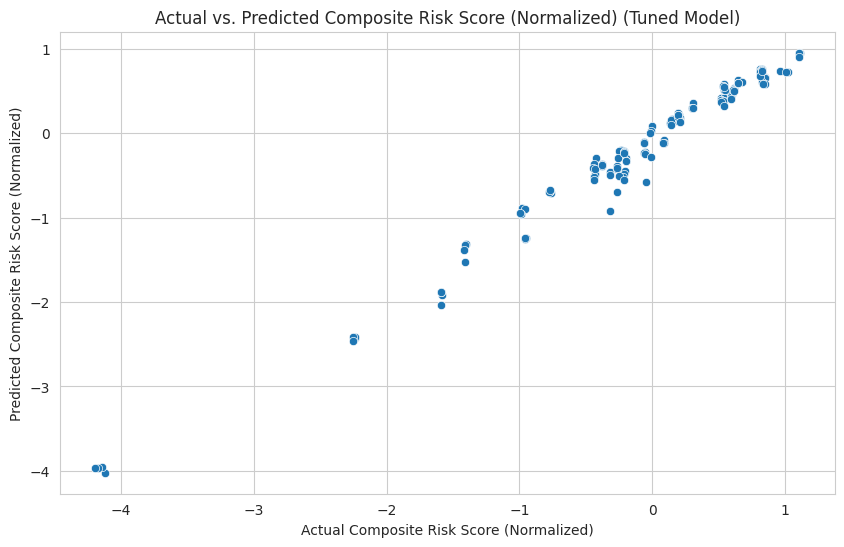

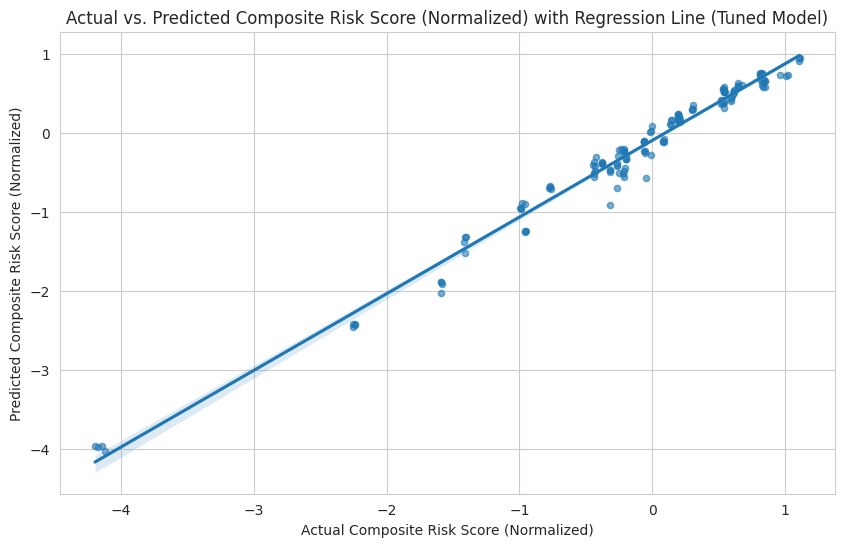

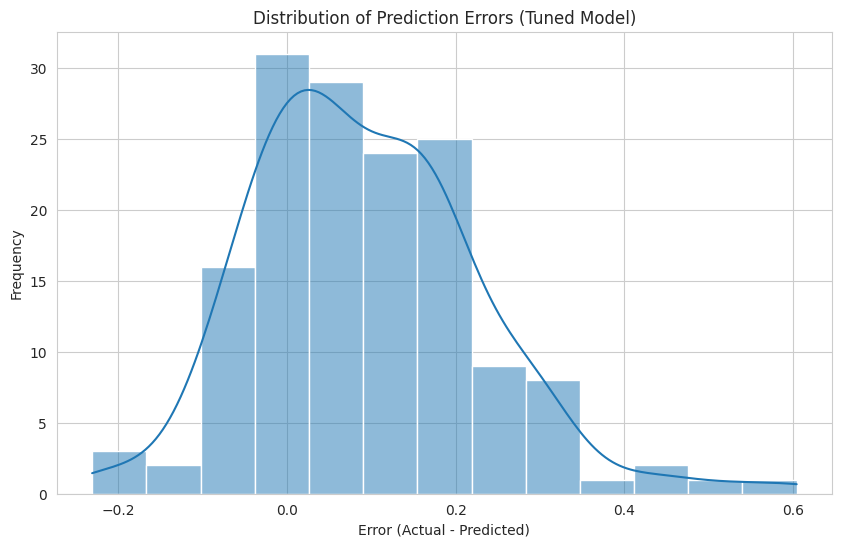

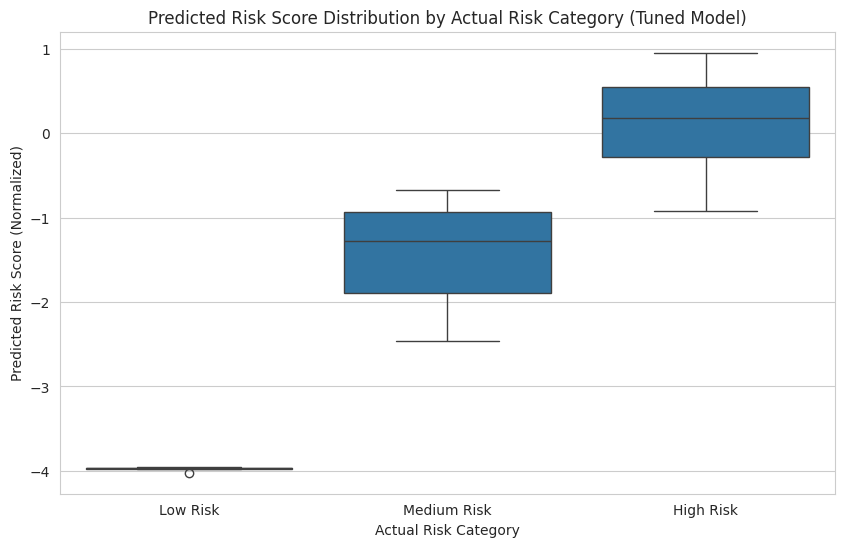

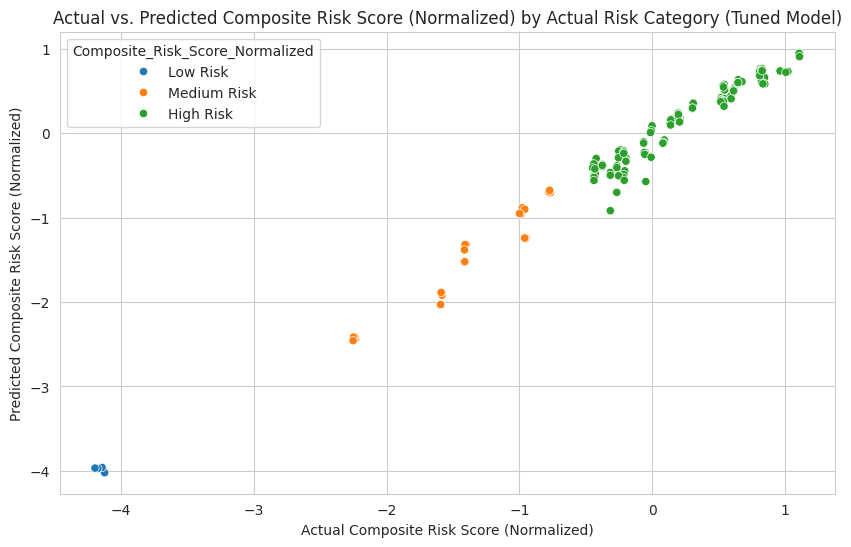

In [21]:
# Visualisasi Actual vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned) # Use y_pred_tuned
plt.title('Actual vs. Predicted Composite Risk Score (Normalized) (Tuned Model)') # Updated title
plt.xlabel('Actual Composite Risk Score (Normalized)')
plt.ylabel('Predicted Composite Risk Score (Normalized)')
plt.show()

# Bisa juga tambahkan garis regresi untuk melihat tren
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_tuned, scatter_kws={'s': 20, 'alpha': 0.6}) # Use y_pred_tuned
plt.title('Actual vs. Predicted Composite Risk Score (Normalized) with Regression Line (Tuned Model)') # Updated title
plt.xlabel('Actual Composite Risk Score (Normalized)')
plt.ylabel('Predicted Composite Risk Score (Normalized)')
plt.show()

# Untuk analisis lebih lanjut, bisa lihat distribusi error
errors = y_test - y_pred_tuned # Use y_pred_tuned for errors
plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True)
plt.title('Distribution of Prediction Errors (Tuned Model)') # Updated title
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

# Analisis berdasarkan kuartil atau rentang risiko
# Anda bisa membagi y_test ke dalam beberapa kategori (misalnya, rendah, sedang, tinggi)
# dan melihat distribusi y_pred di setiap kategori tersebut.

# Contoh: Membagi y_test menjadi 3 kategori (approksimasi)
y_test_quantiles = y_test.quantile([0.33, 0.66])
low_risk_mask = y_test <= y_test_quantiles.iloc[0]
medium_risk_mask = (y_test > y_test_quantiles.iloc[0]) & (y_test <= y_test_quantiles.iloc[1])
high_risk_mask = y_test > y_test_quantiles.iloc[1]

# Create a DataFrame for boxplot
boxplot_data = pd.DataFrame({
    'Predicted_Risk_Score': y_pred_tuned, # Use y_pred_tuned
    'Actual_Risk_Category': pd.cut(y_test, bins=3, labels=['Low Risk', 'Medium Risk', 'High Risk'])
})


plt.figure(figsize=(10, 6))
sns.boxplot(x='Actual_Risk_Category', y='Predicted_Risk_Score', data=boxplot_data)
plt.title('Predicted Risk Score Distribution by Actual Risk Category (Tuned Model)') # Updated title
plt.xlabel('Actual Risk Category')
plt.ylabel('Predicted Risk Score (Normalized)')
plt.show()

# Atau menggunakan scatter plot dengan warna berdasarkan kategori
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, hue=pd.cut(y_test, bins=3, labels=['Low Risk', 'Medium Risk', 'High Risk'])) # Use y_pred_tuned
plt.title('Actual vs. Predicted Composite Risk Score (Normalized) by Actual Risk Category (Tuned Model)') # Updated title
plt.xlabel('Actual Composite Risk Score (Normalized)')
plt.ylabel('Predicted Composite Risk Score (Normalized)')
plt.show()

#Reliability Test

--- Korelasi dengan Persen Penduduk Miskin ---
Pearson Korelasi: 0.6104 (P-value: 0.0000)
Spearman Korelasi: 0.7211 (P-value: 0.0000)


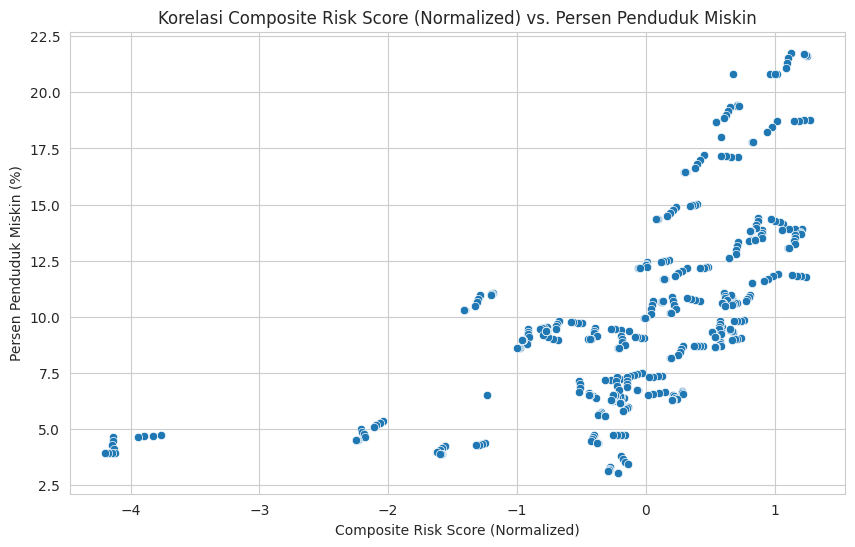


--- Regresi dengan Persen Penduduk Miskin ---
                              OLS Regression Results                              
Dep. Variable:     Persen_Penduduk_Miskin   R-squared:                       0.373
Model:                                OLS   Adj. R-squared:                  0.371
Method:                     Least Squares   F-statistic:                     269.6
Date:                    Wed, 03 Sep 2025   Prob (F-statistic):           6.69e-48
Time:                            07:50:21   Log-Likelihood:                -1196.3
No. Observations:                     456   AIC:                             2397.
Df Residuals:                         454   BIC:                             2405.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

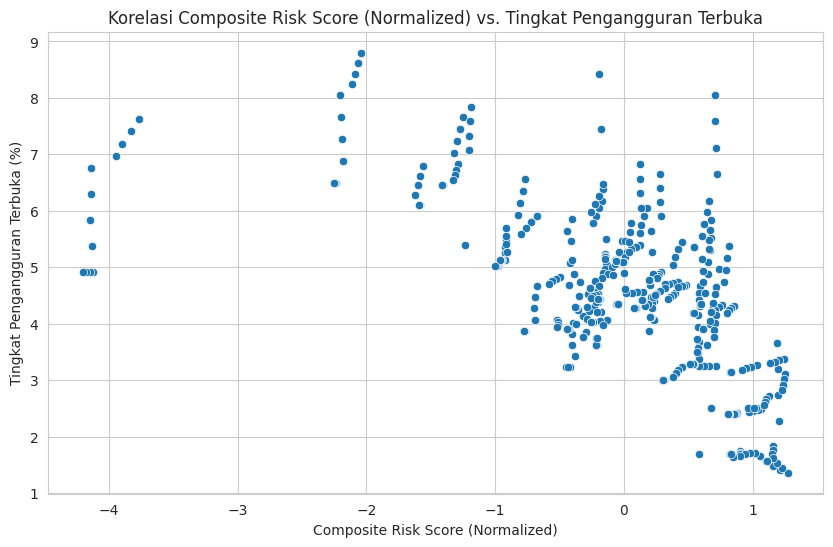


--- Regresi dengan Tingkat Pengangguran Terbuka ---
                                 OLS Regression Results                                 
Dep. Variable:     Tingkat Pengangguran Terbuka   R-squared:                       0.379
Model:                                      OLS   Adj. R-squared:                  0.378
Method:                           Least Squares   F-statistic:                     277.3
Date:                          Wed, 03 Sep 2025   Prob (F-statistic):           6.10e-49
Time:                                  07:50:22   Log-Likelihood:                -704.31
No. Observations:                           456   AIC:                             1413.
Df Residuals:                               454   BIC:                             1421.
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                                      coef    std err    

,tahun,kuartal,Composite_Risk_Score_Normalized,Persen_Penduduk_Miskin,Tingkat Pengangguran Terbuka,PDRB
0,2022,1.0,0.705858,19.44,8.05,4144.62
1,2022,1.0,-0.029049,7.51,5.26,13487.81
2,2022,1.0,-0.195043,3.79,8.43,2993.33
3,2022,1.0,0.446963,8.71,5.45,6591.92
4,2022,1.0,0.482185,12.21,4.69,15712.10


In [36]:
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# --- Korelasi dengan Tingkat Kemiskinan ---

# Gabungkan data risiko komposit (pca_df_train/test) dengan data asli (df_train/test)
# berdasarkan kabupaten_kota, tahun, dan kuartal.
# Kita akan menggunakan data train dan test secara terpisah untuk menghindari data leakage.

# Gabungkan data train, termasuk PDRB
merged_train = pca_df_train.merge(df_train[['kabupaten_kota', 'tahun', 'kuartal', 'Persen_Penduduk_Miskin', 'Tingkat Pengangguran Terbuka', 'PDRB']],
                                  on=['kabupaten_kota', 'tahun', 'kuartal'],
                                  how='left')

# Gabungkan data test, termasuk PDRB
merged_test = pca_df_test.merge(df_test[['kabupaten_kota', 'tahun', 'kuartal', 'Persen_Penduduk_Miskin', 'Tingkat Pengangguran Terbuka', 'PDRB']],
                                on=['kabupaten_kota', 'tahun', 'kuartal'],
                                how='left')

# Gabungkan kembali train dan test untuk analisis korelasi dan regresi
merged_analysis_df = pd.concat([merged_train, merged_test]).reset_index(drop=True)


print("--- Korelasi dengan Persen Penduduk Miskin ---")
# Korelasi Pearson
pearson_corr_kemiskinan, pearson_p_value_kemiskinan = pearsonr(merged_analysis_df['Composite_Risk_Score_Normalized'], merged_analysis_df['Persen_Penduduk_Miskin'])
print(f"Pearson Korelasi: {pearson_corr_kemiskinan:.4f} (P-value: {pearson_p_value_kemiskinan:.4f})")

# Korelasi Spearman
spearman_corr_kemiskinan, spearman_p_value_kemiskinan = spearmanr(merged_analysis_df['Composite_Risk_Score_Normalized'], merged_analysis_df['Persen_Penduduk_Miskin'])
print(f"Spearman Korelasi: {spearman_corr_kemiskinan:.4f} (P-value: {spearman_p_value_kemiskinan:.4f})")

# Visualisasi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_analysis_df, x='Composite_Risk_Score_Normalized', y='Persen_Penduduk_Miskin')
plt.title('Korelasi Composite Risk Score (Normalized) vs. Persen Penduduk Miskin')
plt.xlabel('Composite Risk Score (Normalized)')
plt.ylabel('Persen Penduduk Miskin (%)')
plt.show()

# --- Regresi dengan Persen Penduduk Miskin ---
print("\n--- Regresi dengan Persen Penduduk Miskin ---")
# Definisikan variabel independen (X) dan dependen (y)
X_kemiskinan = merged_analysis_df['Composite_Risk_Score_Normalized']
y_kemiskinan = merged_analysis_df['Persen_Penduduk_Miskin']

# Tambahkan konstanta ke variabel independen untuk intercept
X_kemiskinan = sm.add_constant(X_kemiskinan)

# Fit model regresi OLS (Ordinary Least Squares)
model_kemiskinan = sm.OLS(y_kemiskinan, X_kemiskinan).fit()

# Tampilkan ringkasan hasil regresi
print(model_kemiskinan.summary())


print("\n--- Korelasi dengan Tingkat Pengangguran Terbuka ---")
# Korelasi Pearson
pearson_corr_pengangguran, pearson_p_value_pengangguran = pearsonr(merged_analysis_df['Composite_Risk_Score_Normalized'], merged_analysis_df['Tingkat Pengangguran Terbuka'])
print(f"Pearson Korelasi: {pearson_corr_pengangguran:.4f} (P-value: {pearson_p_value_pengangguran:.4f})")

# Korelasi Spearman
spearman_corr_pengangguran, spearman_p_value_pengangguran = spearmanr(merged_analysis_df['Composite_Risk_Score_Normalized'], merged_analysis_df['Tingkat Pengangguran Terbuka'])
print(f"Spearman Korelasi: {spearman_corr_pengangguran:.4f} (P-value: {spearman_p_value_pengangguran:.4f})")

# Visualisasi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_analysis_df, x='Composite_Risk_Score_Normalized', y='Tingkat Pengangguran Terbuka')
plt.title('Korelasi Composite Risk Score (Normalized) vs. Tingkat Pengangguran Terbuka')
plt.xlabel('Composite Risk Score (Normalized)')
plt.ylabel('Tingkat Pengangguran Terbuka (%)')
plt.show()

# --- Regresi dengan Tingkat Pengangguran Terbuka ---
print("\n--- Regresi dengan Tingkat Pengangguran Terbuka ---")
# Definisikan variabel independen (X) dan dependen (y)
X_pengangguran = merged_analysis_df['Composite_Risk_Score_Normalized']
y_pengangguran = merged_analysis_df['Tingkat Pengangguran Terbuka']

# Tambahkan konstanta ke variabel independen untuk intercept
X_pengangguran = sm.add_constant(X_pengangguran)

# Fit model regresi OLS (Ordinary Least Squares)
model_pengangguran = sm.OLS(y_pengangguran, X_pengangguran).fit()

# Tampilkan ringkasan hasil regresi
print(model_pengangguran.summary())


# Menampilkan data yang digunakan untuk korelasi dan regresi
print("\nData yang Digunakan untuk Korelasi dan Regresi:")
display(merged_analysis_df[['tahun', 'kuartal', 'Composite_Risk_Score_Normalized', 'Persen_Penduduk_Miskin', 'Tingkat Pengangguran Terbuka', 'PDRB']].head())

In [33]:
# --- Segmentasi Data: Kota vs. Kabupaten ---

# Asumsikan kolom 'kabupaten_kota' sudah ada di merged_analysis_df

# Buat kolom baru untuk mengidentifikasi tipe wilayah
# Ini mungkin memerlukan penyesuaian tergantung format nama di kolom 'kabupaten_kota'
merged_analysis_df['Tipe_Wilayah'] = merged_analysis_df['kabupaten_kota'].apply(lambda x: 'Kota' if 'KOTA' in x.strip().upper() else 'Kabupaten')

# Pisahkan DataFrame berdasarkan tipe wilayah
df_kota = merged_analysis_df[merged_analysis_df['Tipe_Wilayah'] == 'Kota'].copy()
df_kabupaten = merged_analysis_df[merged_analysis_df['Tipe_Wilayah'] == 'Kabupaten'].copy()

print("Data berhasil disegmentasi menjadi Kota dan Kabupaten.")
print(f"Jumlah observasi di Kota: {df_kota.shape[0]}")
print(f"Jumlah observasi di Kabupaten: {df_kabupaten.shape[0]}\n")

# --- Analisis untuk Kelompok Kota ---
print("--- Analisis untuk Kelompok Kota ---")

# Korelasi Pearson
if df_kota.shape[0] > 1: # Pastikan ada cukup data untuk korelasi
    pearson_corr_kota, pearson_p_value_kota = pearsonr(df_kota['Composite_Risk_Score_Normalized'], df_kota['Tingkat Pengangguran Terbuka'])
    print(f"Pearson Korelasi (Kota): {pearson_corr_kota:.4f} (P-value: {pearson_p_value_kota:.4f})")
else:
    print("Tidak cukup data di kelompok Kota untuk menghitung korelasi Pearson.")

# Korelasi Spearman
if df_kota.shape[0] > 1: # Pastikan ada cukup data untuk korelasi
    spearman_corr_kota, spearman_p_value_kota = spearmanr(df_kota['Composite_Risk_Score_Normalized'], df_kota['Tingkat Pengangguran Terbuka'])
    print(f"Spearman Korelasi (Kota): {spearman_corr_kota:.4f} (P-value: {spearman_p_value_kota:.4f})")
else:
     print("Tidak cukup data di kelompok Kota untuk menghitung korelasi Spearman.")


# Regresi
if df_kota.shape[0] > 1: # Pastikan ada cukup data untuk regresi
    X_kota = df_kota['Composite_Risk_Score_Normalized']
    y_kota = df_kota['Tingkat Pengangguran Terbuka']
    X_kota = sm.add_constant(X_kota)
    model_kota = sm.OLS(y_kota, X_kota).fit()
    print("\nRegresi (Kota):")
    print(model_kota.summary())
else:
    print("\nTidak cukup data di kelompok Kota untuk menjalankan regresi.")

# Visualisasi (Opsional, bisa ditambahkan jika diinginkan)
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_kota, x='Composite_Risk_Score_Normalized', y='Tingkat Pengangguran Terbuka')
# plt.title('Korelasi CRS vs TPT (Kota)')
# plt.xlabel('Composite Risk Score (Normalized)')
# plt.ylabel('Tingkat Pengangguran Terbuka (%)')
# plt.show()


# --- Analisis untuk Kelompok Kabupaten ---
print("\n--- Analisis untuk Kelompok Kabupaten ---")

# Korelasi Pearson
if df_kabupaten.shape[0] > 1: # Pastikan ada cukup data untuk korelasi
    pearson_corr_kabupaten, pearson_p_value_kabupaten = pearsonr(df_kabupaten['Composite_Risk_Score_Normalized'], df_kabupaten['Tingkat Pengangguran Terbuka'])
    print(f"Pearson Korelasi (Kabupaten): {pearson_corr_kabupaten:.4f} (P-value: {pearson_p_value_kabupaten:.4f})")
else:
    print("Tidak cukup data di kelompok Kabupaten untuk menghitung korelasi Pearson.")

# Korelasi Spearman
if df_kabupaten.shape[0] > 1: # Pastikan ada cukup data untuk korelasi
    spearman_corr_kabupaten, spearman_p_value_kabupaten = spearmanr(df_kabupaten['Composite_Risk_Score_Normalized'], df_kabupaten['Tingkat Pengangguran Terbuka'])
    print(f"Spearman Korelasi (Kabupaten): {spearman_corr_kabupaten:.4f} (P-value: {spearman_p_value_kabupaten:.4f})")
else:
    print("Tidak cukup data di kelompok Kabupaten untuk menghitung korelasi Spearman.")


# Regresi
if df_kabupaten.shape[0] > 1: # Pastikan ada cukup data untuk regresi
    X_kabupaten = df_kabupaten['Composite_Risk_Score_Normalized']
    y_kabupaten = df_kabupaten['Tingkat Pengangguran Terbuka']
    X_kabupaten = sm.add_constant(X_kabupaten)
    model_kabupaten = sm.OLS(y_kabupaten, X_kabupaten).fit()
    print("\nRegresi (Kabupaten):")
    print(model_kabupaten.summary())
else:
    print("\nTidak cukup data di kelompok Kabupaten untuk menjalankan regresi.")

# Visualisasi (Opsional, bisa ditambahkan jika diinginkan)
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_kabupaten, x='Composite_Risk_Score_Normalized', y='Tingkat Pengangguran Terbuka')
# plt.title('Korelasi CRS vs TPT (Kabupaten)')
# plt.xlabel('Composite Risk Score (Normalized)')
# plt.ylabel('Tingkat Pengangguran Terbuka (%)')
# plt.show()

Data berhasil disegmentasi menjadi Kota dan Kabupaten.
Jumlah observasi di Kota: 84
Jumlah observasi di Kabupaten: 372

--- Analisis untuk Kelompok Kota ---
Pearson Korelasi (Kota): -0.5583 (P-value: 0.0000)
Spearman Korelasi (Kota): -0.0595 (P-value: 0.5905)

Regresi (Kota):
                                 OLS Regression Results                                 
Dep. Variable:     Tingkat Pengangguran Terbuka   R-squared:                       0.312
Model:                                      OLS   Adj. R-squared:                  0.303
Method:                           Least Squares   F-statistic:                     37.14
Date:                          Wed, 03 Sep 2025   Prob (F-statistic):           3.42e-08
Time:                                  07:47:39   Log-Likelihood:                -97.558
No. Observations:                            84   AIC:                             199.1
Df Residuals:                                82   BIC:                             204.0
Df Model:  

--- Korelasi dengan PDRB ---
Pearson Korelasi: -0.8476 (P-value: 0.0000)
Spearman Korelasi: -0.5334 (P-value: 0.0000)


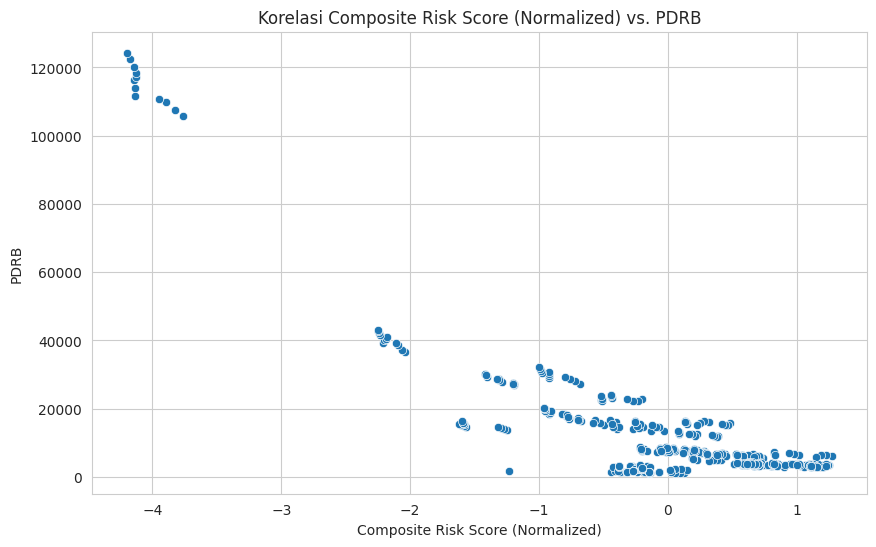


--- Regresi dengan PDRB ---
                            OLS Regression Results                            
Dep. Variable:                   PDRB   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     1158.
Date:                Wed, 03 Sep 2025   Prob (F-statistic):          4.95e-127
Time:                        07:50:42   Log-Likelihood:                -4852.7
No. Observations:                 456   AIC:                             9709.
Df Residuals:                     454   BIC:                             9718.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

,tahun,kuartal,Composite_Risk_Score_Normalized,PDRB
0,2022,1.0,0.705858,4144.62
1,2022,1.0,-0.029049,13487.81
2,2022,1.0,-0.195043,2993.33
3,2022,1.0,0.446963,6591.92
4,2022,1.0,0.482185,15712.10


In [37]:
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# --- Korelasi dan Regresi dengan PDRB ---

# Asumsikan kolom 'PDRB' sudah ada di merged_analysis_df
# Kita akan menggunakan data PDRB yang sudah ada di merged_analysis_df

print("--- Korelasi dengan PDRB ---")
# Korelasi Pearson
pearson_corr_pdrb, pearson_p_value_pdrb = pearsonr(merged_analysis_df['Composite_Risk_Score_Normalized'], merged_analysis_df['PDRB'])
print(f"Pearson Korelasi: {pearson_corr_pdrb:.4f} (P-value: {pearson_p_value_pdrb:.4f})")

# Korelasi Spearman
spearman_corr_pdrb, spearman_p_value_pdrb = spearmanr(merged_analysis_df['Composite_Risk_Score_Normalized'], merged_analysis_df['PDRB'])
print(f"Spearman Korelasi: {spearman_corr_pdrb:.4f} (P-value: {spearman_p_value_pdrb:.4f})")

# Visualisasi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_analysis_df, x='Composite_Risk_Score_Normalized', y='PDRB')
plt.title('Korelasi Composite Risk Score (Normalized) vs. PDRB')
plt.xlabel('Composite Risk Score (Normalized)')
plt.ylabel('PDRB')
plt.show()

# --- Regresi dengan PDRB ---
print("\n--- Regresi dengan PDRB ---")
# Definisikan variabel independen (X) dan dependen (y)
X_pdrb = merged_analysis_df['Composite_Risk_Score_Normalized']
y_pdrb = merged_analysis_df['PDRB']

# Tambahkan konstanta ke variabel independen untuk intercept
X_pdrb = sm.add_constant(X_pdrb)

# Fit model regresi OLS (Ordinary Least Squares)
model_pdrb = sm.OLS(y_pdrb, X_pdrb).fit()

# Tampilkan ringkasan hasil regresi
print(model_pdrb.summary())

# Menampilkan data yang digunakan untuk korelasi dan regresi
print("\nData yang Digunakan untuk Korelasi dan Regresi dengan PDRB:")
display(merged_analysis_df[['tahun', 'kuartal', 'Composite_Risk_Score_Normalized', 'PDRB']].head())

In [39]:
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Uji Robustness: Menghilangkan Satu Indikator ---

print("--- Uji Robustness CRS ---")

# 1. Hitung CRS Versi Final (sudah dilakukan sebelumnya, tapi kita ulangi untuk kejelasan)
# Gunakan pca_df_train dan pca_df_test yang sudah memiliki kolom PC dan arah PC yang disesuaikan.
# Bobot varians dari PCA yang sudah di-fit pada data latih
variance_ratios = pca.explained_variance_ratio_

# Hitung skor komposit terbobot untuk train dan test set
pca_df_train['Composite_Risk_Score_Final'] = pca_df_train[pca_columns].dot(variance_ratios)
pca_df_test['Composite_Risk_Score_Final'] = pca_df_test[pca_columns].dot(variance_ratios)

# Gabungkan kembali train dan test pca_df
pca_df_combined = pd.concat([pca_df_train, pca_df_test]).reset_index(drop=True)

# Normalisasi skor akhir ini secara terpisah untuk train dan test set (menggunakan scaler_risk yang sudah di-fit pada train)
# pca_df_combined['Composite_Risk_Score_Normalized_Final'] = scaler_risk.transform(pca_df_combined[['Composite_Risk_Score_Final']]) # Tidak perlu fit lagi

# Menggunakan skor yang sudah dinormalisasi dari langkah sebelumnya (cell 3Inh7etSjIqr)
# merged_analysis_df sudah berisi 'Composite_Risk_Score_Normalized' yang merupakan CRS final.
# Kita akan menggunakan merged_analysis_df untuk analisis ini.
# Pastikan merged_analysis_df memiliki semua kolom fitur asli yang digunakan dalam PCA.
# merge merged_analysis_df with original df to get original features
merged_analysis_with_features = merged_analysis_df.merge(df[['kabupaten_kota', 'tahun', 'kuartal'] + pca_cols],
                                                         on=['kabupaten_kota', 'tahun', 'kuartal'],
                                                         how='left')


original_crs_normalized = merged_analysis_with_features['Composite_Risk_Score_Normalized']


# 2. Buat Versi Alternatif CRS dengan Menghilangkan Satu Per Guru Indikator
robustness_results = {}

# Iterate through each original PCA input column (pca_cols)
for col_to_remove in pca_cols:
    print(f"\n--- Menghilangkan '{col_to_remove}' ---")

    # Select features excluding the one to remove
    features_for_pca = [col for col in pca_cols if col != col_to_remove]

    if not features_for_pca:
        print(f"Tidak ada fitur tersisa setelah menghapus '{col_to_remove}'. Melewati.")
        continue

    # Lakukan Standardisasi dan PCA ulang pada data TRAINING SAJA
    # Menggunakan data training asli (df_train) dan scaler yang baru
    X_train_robustness_raw = df_train[features_for_pca].copy()
    X_test_robustness_raw = df_test[features_for_pca].copy()

    # Tangani pemisah desimal koma jika ada (sesuai preprocessing awal)
    for df_feat in [X_train_robustness_raw, X_test_robustness_raw]:
         if 'Laju_Inflasi' in df_feat.columns:
            df_feat['Laju_Inflasi'] = df_feat['Laju_Inflasi'].astype(str).str.replace(',', '.', regex=False)
            df_feat['Laju_Inflasi'] = pd.to_numeric(df_feat['Laju_Inflasi'], errors='coerce')


    scaler_robustness = StandardScaler()
    X_train_scaled_robustness = scaler_robustness.fit_transform(X_train_robustness_raw)

    # Fit PCA pada data training yang sudah distandardisasi
    pca_robustness = PCA()
    pca_robustness.fit(X_train_scaled_robustness)

    # Tentukan jumlah komponen untuk menjelaskan >90% varians (atau n_components yang sama dengan PCA awal)
    # Kita gunakan jumlah komponen yang sama dengan PCA awal (n_components) untuk konsistensi
    n_components_robustness = n_components # Use the n_components from the original PCA

    if n_components_robustness > X_train_scaled_robustness.shape[1]:
         print(f"Jumlah komponen PCA ({n_components_robustness}) lebih besar dari jumlah fitur tersisa ({X_train_scaled_robustness.shape[1]}). Menyesuaikan n_components.")
         n_components_robustness = X_train_scaled_robustness.shape[1]
         if n_components_robustness == 0:
             print("Tidak ada fitur tersisa untuk PCA. Melewati.")
             continue


    # Ulangi PCA dengan n_components_robustness yang optimal, fit pada training, transform pada train & test
    pca_robustness = PCA(n_components=n_components_robustness)
    pca_scores_train_robustness = pca_robustness.fit_transform(X_train_scaled_robustness)

    # Transform test data using scaler and PCA fitted on training
    X_test_scaled_robustness = scaler_robustness.transform(X_test_robustness_raw)
    pca_scores_test_robustness = pca_robustness.transform(X_test_scaled_robustness)


    # Buat DataFrame hasil PCA untuk training dan testing
    pca_columns_robustness = [f'PC{i+1}' for i in range(n_components_robustness)]

    pca_df_train_robustness = pd.DataFrame(pca_scores_train_robustness, columns=pca_columns_robustness)
    pca_df_train_robustness = pd.concat([df_train[['kabupaten_kota', 'tahun', 'kuartal']].reset_index(drop=True), pca_df_train_robustness], axis=1)

    pca_df_test_robustness = pd.DataFrame(pca_scores_test_robustness, columns=pca_columns_robustness)
    pca_df_test_robustness = pd.concat([df_test[['kabupaten_kota', 'tahun', 'kuartal']].reset_index(drop=True), pca_df_test_robustness], axis=1)

    # Gabungkan kembali training dan testing pca_df
    pca_df_combined_robustness = pd.concat([pca_df_train_robustness, pca_df_test_robustness]).reset_index(drop=True)


    # Dapatkan bobot varians dari PCA yang baru
    variance_ratios_robustness = pca_robustness.explained_variance_ratio_

    # Hitung skor komposit terbobot untuk versi alternatif
    # Pastikan jumlah kolom PC sesuai dengan variance_ratios_robustness
    if len(pca_columns_robustness) != len(variance_ratios_robustness):
        print(f"Jumlah komponen PC ({len(pca_columns_robustness)}) tidak sesuai dengan jumlah rasio varians ({len(variance_ratios_robustness)}). Melewati perhitungan skor komposit.")
        continue


    pca_df_combined_robustness['Composite_Risk_Score_Alternative'] = pca_df_combined_robustness[pca_columns_robustness].dot(variance_ratios_robustness)


    # Normalisasi skor alternatif menggunakan scaler_risk yang di-fit pada CRS final
    # Gunakan scaler_risk yang sudah di-fit pada CRS final (dari cell 3Inh7etSjIqr)
    # Pastikan nama kolom sesuai dengan yang diharapkan oleh scaler_risk
    # scaler_risk was fitted on 'Composite_Risk_Score' before normalization, so we need to use that column name for transformation
    # Let's assume scaler_risk expects a column named 'Composite_Risk_Score'
    # To be safe, let's fit a NEW scaler for each alternative CRS on its training data and transform on test.
    # This avoids potential issues if the scale of the alternative CRS is vastly different.

    # Split back into train/test for scaling
    df_train_robustness = pca_df_combined_robustness.iloc[:len(df_train)].copy()
    df_test_robustness = pca_df_combined_robustness.iloc[len(df_train):].copy()


    scaler_alternative_risk = StandardScaler()
    df_train_robustness['Composite_Risk_Score_Alternative_Normalized'] = scaler_alternative_risk.fit_transform(df_train_robustness[['Composite_Risk_Score_Alternative']])
    df_test_robustness['Composite_Risk_Score_Alternative_Normalized'] = scaler_alternative_risk.transform(df_test_robustness[['Composite_Risk_Score_Alternative']])

    # Gabungkan kembali
    pca_df_combined_robustness['Composite_Risk_Score_Alternative_Normalized'] = pd.concat([df_train_robustness['Composite_Risk_Score_Alternative_Normalized'], df_test_robustness['Composite_Risk_Score_Alternative_Normalized']]).reset_index(drop=True)


    # 3. Hitung Korelasi antara CRS Versi Final dan Alternatif
    # Gunakan merged_analysis_with_features untuk CRS final yang dinormalisasi
    # Gunakan pca_df_combined_robustness untuk CRS alternatif yang dinormalisasi

    # Merge CRS Final dan CRS Alternatif berdasarkan identifier yang sama
    merged_crs = merged_analysis_with_features[['kabupaten_kota', 'tahun', 'kuartal', 'Composite_Risk_Score_Normalized']].merge(
        pca_df_combined_robustness[['kabupaten_kota', 'tahun', 'kuartal', 'Composite_Risk_Score_Alternative_Normalized']],
        on=['kabupaten_kota', 'tahun', 'kuartal'],
        how='inner'
    )

    if merged_crs.shape[0] > 1:
        correlation, p_value = pearsonr(merged_crs['Composite_Risk_Score_Normalized'], merged_crs['Composite_Risk_Score_Alternative_Normalized'])
        robustness_results[col_to_remove] = {'correlation': correlation, 'p_value': p_value}
        print(f"Korelasi Pearson: {correlation:.4f} (P-value: {p_value:.4f})")
    else:
        print("Tidak cukup data setelah penggabungan untuk menghitung korelasi.")
        robustness_results[col_to_remove] = {'correlation': np.nan, 'p_value': np.nan}


# 4. Tampilkan Hasil Interpretasi
print("\n--- Hasil Uji Robustness ---")
for col, result in robustness_results.items():
    corr = result['correlation']
    p_val = result['p_value']
    if not np.isnan(corr):
        print(f"Menghilangkan '{col}': Korelasi dengan CRS Final = {corr:.4f} (P-value: {p_val:.4f})")
        # Check absolute value for robustness
        if abs(corr) > 0.9 and p_val < 0.05:
            print("   -> Robust (Korelasi sangat tinggi dan signifikan)")
        elif abs(corr) > 0.6 and p_val < 0.05:
             print("   -> Cukup Robust (Korelasi tinggi dan signifikan)")
        else:
            print("   -> Kurang Robust (Korelasi rendah atau tidak signifikan)")
    else:
        print(f"Menghilangkan '{col}': Tidak dapat menghitung korelasi.")

--- Uji Robustness CRS ---

--- Menghilangkan 'Garis_Kemiskinan' ---
Korelasi Pearson: -0.9352 (P-value: 0.0000)

--- Menghilangkan 'Indeks_Pembangunan_Manusia' ---
Korelasi Pearson: -0.9276 (P-value: 0.0000)

--- Menghilangkan 'Persen_Penduduk_Miskin' ---
Korelasi Pearson: -0.9696 (P-value: 0.0000)

--- Menghilangkan 'Tingkat Pengangguran Terbuka' ---
Korelasi Pearson: -0.9750 (P-value: 0.0000)

--- Menghilangkan 'Upah Minimum' ---
Korelasi Pearson: -0.9236 (P-value: 0.0000)

--- Menghilangkan 'Jumlah Penduduk (Ribu)' ---
Korelasi Pearson: -0.9390 (P-value: 0.0000)

--- Menghilangkan 'Laju Pertumbuhan Penduduk per Tahun' ---
Korelasi Pearson: -0.9506 (P-value: 0.0000)

--- Menghilangkan 'Persentase Penduduk' ---
Korelasi Pearson: -0.9392 (P-value: 0.0000)

--- Menghilangkan 'Kepadatan Penduduk per km persegi (Km2)' ---
Korelasi Pearson: -0.9224 (P-value: 0.0000)

--- Menghilangkan 'Rasio Jenis Kelamin Penduduk' ---
Korelasi Pearson: -0.9973 (P-value: 0.0000)

--- Menghilangkan 'PDRB' 

In [43]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
import numpy as np

# --- Time Series Cross-Validation ---

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5) # You can adjust the number of splits

# Initialize lists to store scores
r2_scores_cv = []
mae_scores_cv = []

# Perform cross-validation
print("Performing Time Series Cross-Validation...")
for train_index, test_index in tscv.split(X_train):
    # Split data based on the indices
    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Initialize and train the model
    # Using the tuned model parameters found earlier
    cv_model = xgb.XGBRegressor(**tuned_xgb_model.get_params()) # Use get_params() from the tuned model

    cv_model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred_fold = cv_model.predict(X_test_fold)

    # Evaluate and store scores
    r2_cv = r2_score(y_test_fold, y_pred_fold)
    mae_cv = mean_absolute_error(y_test_fold, y_pred_fold)

    r2_scores_cv.append(r2_cv)
    mae_scores_cv.append(mae_cv)
    print(f"  Fold R-squared: {r2_cv:.4f}, Fold MAE: {mae_cv:.4f}")

# Calculate and print the average scores
print("\n--- Cross-Validation Results ---")
print(f"Average R-squared: {np.mean(r2_scores_cv):.4f} +/- {np.std(r2_scores_cv):.4f}")
print(f"Average MAE: {np.mean(mae_scores_cv):.4f} +/- {np.std(mae_scores_cv):.4f}")

Performing Time Series Cross-Validation...
  Fold R-squared: 0.9952, Fold MAE: 0.0461
  Fold R-squared: 0.9901, Fold MAE: 0.0742
  Fold R-squared: 0.9585, Fold MAE: 0.1411
  Fold R-squared: 0.9626, Fold MAE: 0.0989
  Fold R-squared: 0.9927, Fold MAE: 0.0670

--- Cross-Validation Results ---
Average R-squared: 0.9798 +/- 0.0158
Average MAE: 0.0855 +/- 0.0326


#SHAP Analysis

--- SHAP Summary Plot (Global Feature Importance) ---


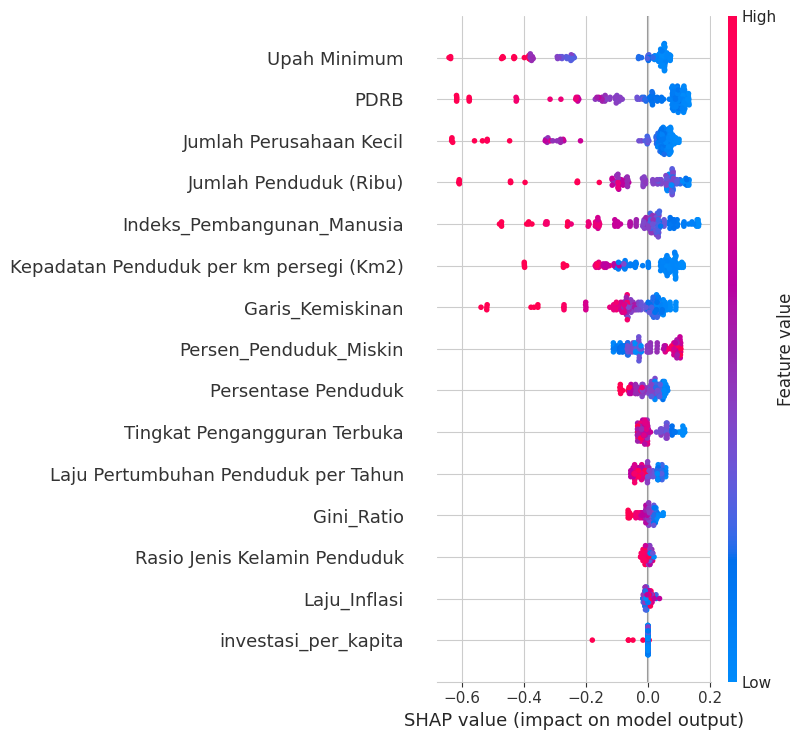


--- SHAP Dependence Plot for 'Garis_Kemiskinan' ---


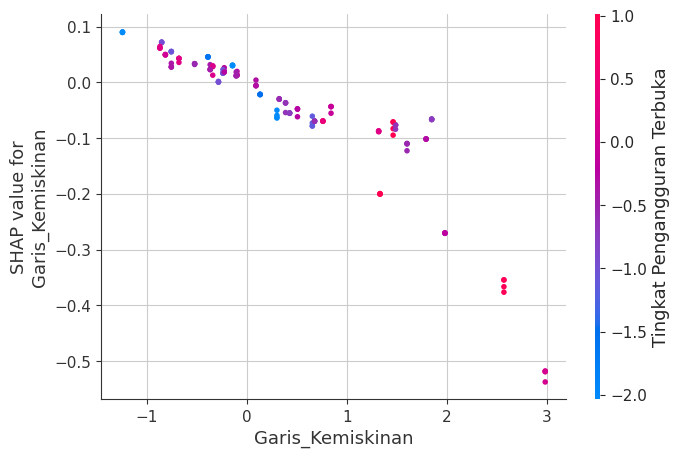


--- SHAP Force Plot for a Single Prediction (Index 0) ---

--- SHAP Force Plot for Multiple Predictions (First 10) ---


In [22]:
import shap

# --- Analisis SHAP ---

# SHAP (SHapley Additive exPlanations) membantu menjelaskan output dari model
# dengan menghitung kontribusi setiap fitur untuk setiap prediksi.

# Inisialisasi JS visualization library (hanya perlu sekali)
shap.initjs()

# Buat Explainer SHAP untuk model XGBoost yang sudah di-tune
# Gunakan data training (atau subset dari data training) sebagai background dataset
# karena SHAP explainer berbasis tree (seperti XGBoost) lebih efisien dengan cara ini.
# X_train adalah DataFrame fitur training yang sudah dinormalisasi.
explainer = shap.TreeExplainer(tuned_xgb_model, X_train)

# Hitung SHAP values untuk data test (X_test)
# Ini akan memberikan kontribusi setiap fitur untuk setiap observasi di data test.
shap_values = explainer.shap_values(X_test)

# --- Visualisasi SHAP ---

# 1. Summary Plot: Melihat pentingnya fitur secara keseluruhan
# Plot ini menunjukkan fitur mana yang paling penting dan bagaimana mereka mempengaruhi output model.
# Warna menunjukkan nilai fitur (merah = tinggi, biru = rendah).
print("--- SHAP Summary Plot (Global Feature Importance) ---")
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

# 2. Dependence Plot: Melihat bagaimana satu fitur mempengaruhi output model
# Pilih salah satu fitur penting dari summary plot untuk divisualisasikan.
# Ganti 'Nama_Fitur_Penting' dengan nama fitur yang ingin Anda analisis.
# Contoh: 'Garis_Kemiskinan'
# Pastikan nama fitur ada di X_test.columns
if 'Garis_Kemiskinan' in X_test.columns:
    print("\n--- SHAP Dependence Plot for 'Garis_Kemiskinan' ---")
    shap.dependence_plot("Garis_Kemiskinan", shap_values, X_test, feature_names=X_test.columns)
else:
    print("\nFitur 'Garis_Kemiskinan' tidak ditemukan di data test untuk dependence plot.")

# Anda bisa menambahkan dependence plot untuk fitur penting lainnya.
# if 'Indeks_Pembangunan_Manusia' in X_test.columns:
#     print("\n--- SHAP Dependence Plot for 'Indeks_Pembangunan_Manusia' ---")
#     shap.dependence_plot("Indeks_Pembangunan_Manusia", shap_values, X_test, feature_names=X_test.columns)

# 3. Force Plot (Individual Prediction Explanation): Menjelaskan satu prediksi
# Pilih salah satu indeks observasi dari data test (misal indeks 0).
# Plot ini menunjukkan bagaimana setiap fitur mendorong prediksi dari base value.
print("\n--- SHAP Force Plot for a Single Prediction (Index 0) ---")
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:], feature_names=X_test.columns)

# 4. Force Plot (Multiple Predictions): Menjelaskan beberapa prediksi
# Pilih rentang indeks observasi dari data test.
# Plot ini menunjukkan tren kontribusi fitur di beberapa observasi.
print("\n--- SHAP Force Plot for Multiple Predictions (First 10) ---")
shap.force_plot(explainer.expected_value, shap_values[:10,:], X_test.iloc[:10,:], feature_names=X_test.columns)

# Catatan:
# - SHAP plots mungkin memerlukan waktu untuk dirender, terutama untuk dataset besar.
# - Interpretasi plot SHAP memerlukan pemahaman tentang domain data dan model.

#Saving Pipeline

In [52]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Assume X_train_raw (raw features from df_train) is available from previous steps (e.g., cell 7VfL379kM-69)
# Assume y_train (normalized composite risk score) is available
# Assume the tuned XGBoost model 'tuned_xgb_model' is available from previous steps (e.g., cell QoNjgu9zVAu-)

# Define the pipeline steps
# Step 1: Standardize the raw features
scaler_step = ('scaler', StandardScaler())

# Step 2: Use the tuned XGBoost model
model_step = ('xgb_model', tuned_xgb_model)

# Create the pipeline without the PCA step
full_pipeline = Pipeline([
    scaler_step,
    model_step
])

# Train the entire pipeline on the raw training data features (X_train_raw)
# The scaler in the pipeline will be fitted on X_train_raw
# The xgb_model will be trained on the scaled data
# Recreate X_train_raw for clarity and to ensure it's based on original df_train
exclude_cols = ['kabupaten_kota', 'tahun', 'kuartal', 'Proksi Inflasi']
X_train_raw = df_train.drop(columns=exclude_cols, errors='ignore')

# Handle comma decimal in 'Laju_Inflasi' if necessary (consistent with training preprocessing)
if 'Laju_Inflasi' in X_train_raw.columns:
    X_train_raw['Laju_Inflasi'] = X_train_raw['Laju_Inflasi'].astype(str).str.replace(',', '.', regex=False)
    X_train_raw['Laju_Inflasi'] = pd.to_numeric(X_train_raw['Laju_Inflasi'], errors='coerce')


full_pipeline.fit(X_train_raw, y_train)


# Simpan SATU file pipeline yang berisi semuanya
joblib.dump(full_pipeline, 'risk_prediction_pipeline.pkl')

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [53]:
import pandas as pd
import joblib

# Nanti saat memprediksi data baru:
loaded_pipeline = joblib.load('risk_prediction_pipeline.pkl')

# Load the new data from the CSV file into a pandas DataFrame
new_data = pd.read_csv('Data_for_Model_v3.csv')

exclude_cols = ['kabupaten_kota', 'tahun', 'kuartal', 'Proksi Inflasi']
new_data_features = new_data.drop(columns=exclude_cols, errors='ignore')

# Handle comma decimal in 'Laju_Inflasi' if necessary (consistent with training preprocessing)
if 'Laju_Inflasi' in new_data_features.columns:
    new_data_features['Laju_Inflasi'] = new_data_features['Laju_Inflasi'].astype(str).str.replace(',', '.', regex=False)
    new_data_features['Laju_Inflasi'] = pd.to_numeric(new_data_features['Laju_Inflasi'], errors='coerce')

# Make predictions using the loaded pipeline
new_prediction = loaded_pipeline.predict(new_data_features)

# You might want to add the predictions back to the original new_data DataFrame
new_data['Predicted_Composite_Risk_Score_Normalized'] = new_prediction

print("Predictions made successfully!")
display(new_data.head())

Predictions made successfully!


,kabupaten_kota,Garis_Kemiskinan,Indeks_Pembangunan_Manusia,Persen_Penduduk_Miskin,Tingkat Pengangguran Terbuka,Upah Minimum,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk,tahun,kuartal,PDRB,Proksi Inflasi,Laju_Inflasi,Gini_Ratio,investasi_per_kapita,Jumlah Perusahaan Kecil,Predicted_Composite_Risk_Score_Normalized
0,BANGKALAN,458754,66.11,19.44,8.05,1956773.48,1081.75,1.25,2.62,954.5,97.4,2022,1.0,4144.62,Kota Surabaya,3.16,0.306,331.467391,38,0.705505
1,BANGKALAN,458754,66.11,19.44,8.05,1956773.48,1081.75,1.25,2.62,954.5,97.4,2022,2.0,4184.80,Kota Surabaya,4.89,0.306,986.404348,37,0.714288
2,BANGKALAN,458754,66.11,19.44,8.05,1956773.48,1081.75,1.25,2.62,954.5,97.4,2022,3.0,4481.15,Kota Surabaya,6.91,0.306,1527.247619,39,0.725526
3,BANGKALAN,458754,66.11,19.44,8.05,1956773.48,1081.75,1.25,2.62,954.5,97.4,2022,4.0,4149.34,Kota Surabaya,6.59,0.306,1103.961538,44,0.725715
4,BANGKALAN,503207,66.82,19.35,6.18,2240701.00,1091.80,1.07,2.63,839.0,97.6,2023,1.0,4304.99,Kota Surabaya,6.3,0.299,2403.400000,46,0.657210


--- Correlation between Original and Predicted Composite Risk Score ---
Pearson Korelasi: 0.9949 (P-value: 0.0000)
Spearman Korelasi: 0.9908 (P-value: 0.0000)


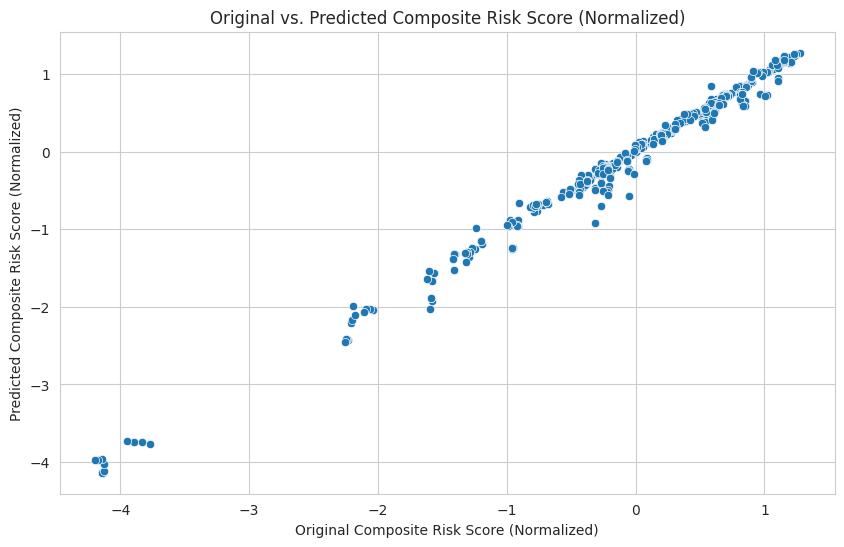


Data used for correlation:


,kabupaten_kota,tahun,kuartal,Composite_Risk_Score_Normalized,Predicted_Composite_Risk_Score_Normalized
0,BANGKALAN,2022,1.0,0.705858,0.705505
1,BANYUWANGI,2022,1.0,-0.029049,-0.029175
2,BATU,2022,1.0,-0.195043,-0.194520
3,BLITAR,2022,1.0,0.446963,0.446945
4,BOJONEGORO,2022,1.0,0.482185,0.480609


In [54]:
from scipy.stats import pearsonr, spearmanr

# Assuming 'new_data' contains the 'Predicted_Composite_Risk_Score_Normalized'
# and 'merged_analysis_df' contains the original 'Composite_Risk_Score_Normalized'
# We need to merge these two dataframes based on common identifiers (kabupaten_kota, tahun, kuartal)

# Ensure merged_analysis_df has the necessary columns
# It was created by concatenating merged_train and merged_test which included these columns
# Display merged_analysis_df.head() to confirm its structure if needed

# Select relevant columns from new_data
predicted_scores = new_data[['kabupaten_kota', 'tahun', 'kuartal', 'Predicted_Composite_Risk_Score_Normalized']]

# Merge with the dataframe containing the original Composite Risk Score
# merged_analysis_df already contains the original 'Composite_Risk_Score_Normalized'
correlation_comparison_df = merged_analysis_df.merge(
    predicted_scores,
    on=['kabupaten_kota', 'tahun', 'kuartal'],
    how='inner' # Use inner merge to only include rows present in both dataframes
)

# Check if the merged dataframe is not empty
if correlation_comparison_df.shape[0] > 1:
    print("--- Correlation between Original and Predicted Composite Risk Score ---")

    # Pearson Correlation
    pearson_corr_pred_orig, pearson_p_value_pred_orig = pearsonr(
        correlation_comparison_df['Composite_Risk_Score_Normalized'],
        correlation_comparison_df['Predicted_Composite_Risk_Score_Normalized']
    )
    print(f"Pearson Korelasi: {pearson_corr_pred_orig:.4f} (P-value: {pearson_p_value_pred_orig:.4f})")

    # Spearman Correlation
    spearman_corr_pred_orig, spearman_p_value_pred_orig = spearmanr(
        correlation_comparison_df['Composite_Risk_Score_Normalized'],
        correlation_comparison_df['Predicted_Composite_Risk_Score_Normalized']
    )
    print(f"Spearman Korelasi: {spearman_corr_pred_orig:.4f} (P-value: {spearman_p_value_pred_orig:.4f})")

    # Optional: Visualize the correlation
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=correlation_comparison_df,
                    x='Composite_Risk_Score_Normalized',
                    y='Predicted_Composite_Risk_Score_Normalized')
    plt.title('Original vs. Predicted Composite Risk Score (Normalized)')
    plt.xlabel('Original Composite Risk Score (Normalized)')
    plt.ylabel('Predicted Composite Risk Score (Normalized)')
    plt.show()

    print("\nData used for correlation:")
    display(correlation_comparison_df[['kabupaten_kota', 'tahun', 'kuartal', 'Composite_Risk_Score_Normalized', 'Predicted_Composite_Risk_Score_Normalized']].head())

else:
    print("Not enough data after merging to calculate correlation.")